# <span style="color:red; font-size:25px"> DATASCI 151 - Quiz #4 </span>

<font size = "4" >
This quiz is open book 

<br>

- You <span style="color:red"> CAN </span> use all material from the course repo

- You should <span style="color:red"> NOT </span> use other resources outside the course repo.

- You should <span style="color:red"> NOT </span> collaborate with other students

<!-- - This is a graded quiz. Use of LLMs or any AI tools is <span style="color:red"> NOT ALLOWED. </span> -->

- AI assistance is <span style="color:red"> NOT </span> permitted for this assignment.

- To get full credit, the code should work as intended. But try to attempt every problem - you can still receive partial credit.

<br>

Print the following string:

"I will abide by Emory's code of conduct"

In [70]:
print("I will abide by Emory's code of conduct")

I will abide by Emory's code of conduct


<font size = "4">

Import any packages you would like in the cell below. Or, import them as needed later in the notebook.

In [71]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<font size = "4">

**Q1** Transforming variables

<font size = "3">

During a roadside physics study, researchers measured the speed of various vehicles as they passed a checkpoint using a radar gun. The mass of each vehicle was estimated based on manufacturer specifications for the vehicle model.

The speeds were recorded in **miles per hour (mph)** and masses were recorded in **kilograms (kg)**.

1. Read in the file "speed_mass.csv" from the quiz_data folder, saving it as a DataFrame

2. Using the `.apply` method, define a Pandas Series that contains the speed in terms of **meters per second** based on the following formula:

$$ \textrm{speed in meters per second} = \frac{1609.34}{3600} \times \textrm{speed in miles per hour}$$

3. Add a new column to the DataFrame named "Kinetic Energy (J)" which contains the kinetic energy of the car. The formula for kinetic energy is given below, where $m$ is the mass in kilograms and $v$ is the velocity in meters per second.

$$ \textrm{kinetic energy} = \frac{1}{2}mv^2$$

In [72]:
# your code here
df_speed_mass = pd.read_csv('quiz_data/speed_mass.csv')

def mph_to_ms(speed):
    return (1609.34 / 3600 * speed)

df_speed_mass["Speed (m/s)"] = df_speed_mass["Speed (mph)"].apply(mph_to_ms)

kinetic_energy = (1/2) * df_speed_mass["Mass (kg)"] * (df_speed_mass["Speed (m/s)"] ** 2)
df_speed_mass["Kinetic Energy (J)"] = kinetic_energy

df_speed_mass.head()

,Vehicle ID,Speed (mph),Mass (kg),Speed (m/s),Kinetic Energy (J)
0,QA22,42.5,1441.67,18.999153,260198.228635
1,TR80,77.0,1577.65,34.421994,934657.997612
2,KA25,63.9,2276.71,28.565785,928902.316140
3,AF65,55.9,1475.38,24.989474,460668.081390
4,FP80,29.4,1254.24,13.142943,108326.802019


<font size = "4">

**Q2** Random Assignment

<font size = "3">

Read in the file "SOCR-HeightWeight.csv" from the quiz_data folder, storing it as a DataFrame. It contains two columns "Height(Inches)" and "Weight(pounds)".

1. Use some method to randomly assign each person in the dataset into four groups: 1, 2, 3, 4. Each group should be assigned with equal probability (25% chance of being placed in a given group). You can use any appropriate method to peform the random assignment.

2. Add a new column to the DataFrame with the name "GroupID", where each entry is either 1, 2, 3, or 4.


In [73]:
# your code here
df_SOCR = pd.read_csv('quiz_data/SOCR-HeightWeight.csv')

n = len(df_SOCR)
groupID = np.random.choice(["1", "2", "3", "4"], size = n)
df_SOCR["GroupID"] = groupID

df_SOCR.head()

,Height(Inches),Weight(Pounds),GroupID
0,65.78331,112.9925,3
1,71.51521,136.4873,4
2,69.39874,153.0269,1
3,68.21660,142.3354,4
4,67.78781,144.2971,4


<font size = "4">

**Q3** Random assignment

<font size = "3">

Continue to use the DataFrame you created in **Q3**

1. Use `.query` to extract all players in Group 1, assigning it to a new DataFrame called `group_1`

2. Use `.query` to extract all players in Group 2, assigning it to a new DataFrame called `group_2`

3. Use ``matplotlib.pyplot.subplots`` to create two side by side scatter plots (1 row, 2 columns)

    - In the left figure, plot the columns ``Height(Inches)`` vs. ``Weight(Pounds)`` for the data in ``group_1`` (so the horizontal axis corresponds to height, the vertical axis corresponds to weight)

    - In the right figure, plot the same variables for ``group_2``

    - Label the axes for **both** plots. Create a title for **both** plots, indicating whether Group 1 or Group 2 is shown.

**Note**: If you can't remember how to use `.subplots`, maximize your partial credit by using two calls to `.scatter` to create two separate plots.

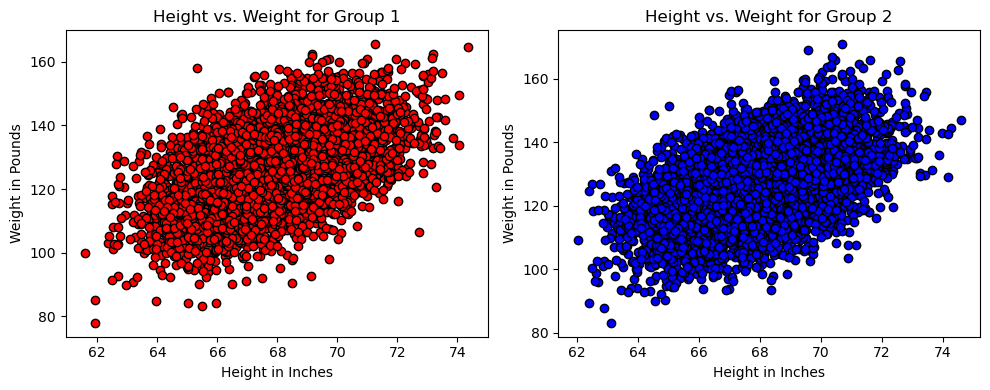

In [74]:
# your code here
group_1 = df_SOCR.query("GroupID == '1'")
group_2 = df_SOCR.query("GroupID == '2'")

fig, subplt = plt.subplots(nrows = 1, ncols = 2,figsize = (10,4))

subplt[0].scatter(x = group_1["Height(Inches)"], y = group_1["Weight(Pounds)"], color = "red", edgecolor = "black")
subplt[0].set_title("Height vs. Weight for Group 1")
subplt[0].set_xlabel("Height in Inches")
subplt[0].set_ylabel("Weight in Pounds")

subplt[1].scatter(x = group_2["Height(Inches)"], y = group_2["Weight(Pounds)"], color = "blue", edgecolor = "black")
subplt[1].set_title("Height vs. Weight for Group 2")
subplt[1].set_xlabel("Height in Inches")
subplt[1].set_ylabel("Weight in Pounds")

plt.tight_layout()

<font size = "4">

**Q4** Recoding Variables

<font size = "3">

Read in the file "datasci185.csv" from the quiz_data folder, assigning it to a DataFrame. The file is a (hypothetical) dataset of students taking DataSci 185 with the columns "Student_ID", "Major", "Year", and "Grade Pct".

1. Recode the "Grade Pct" variable into a categorical variable with the values:

    - "F" if $\textrm{Grade\_Pct} < 55$
    - "D" if $55 \leq \textrm{Grade\_Pct} < 60$
    - "C" if $60 \leq \textrm{Grade\_Pct} < 75$
    - "B" if $75 \leq \textrm{Grade\_Pct} < 87$
    - "A" if $87 \leq \textrm{Grade\_Pct}$

2. Add a column to the DataFrame called "Letter_Grade" corresponding to this new categorical variable.

3. Using Python/Pandas commands, calculate and print out the proportion of "A" students in the course (# of "A" students / # of total students). 

**Note:** Unlike the examples in class, the right endpoint of the intervals/bins are **not** inclusive, but the left ones are!


In [75]:
# your code here
df_students = pd.read_csv('quiz_data/datasci185.csv')

def check_grades(Grade_Pct):
    if Grade_Pct < 55:
        return "F" 
    elif Grade_Pct < 60:
        return "D"
    elif Grade_Pct < 75:
        return "C"
    elif Grade_Pct < 87:
        return "B"
    elif Grade_Pct >= 87:
        return "A"
    
df_students["Letter_Grade"] = df_students["Grade Pct"].apply(check_grades)
print(df_students)

A_students = len(df_students.query("Letter_Grade == 'A'")) / len(df_students)

print("The proportion of 'A' students is:", A_students)

    Student_ID                   Major       Year  Grade Pct Letter_Grade
0          419  Environmental Sciences     Senior       88.9            A
1         5381            Anthropology   Freshman       92.1            A
2        33204  Environmental Sciences  Sophomore       83.6            B
3         5034                 Physics  Sophomore       99.5            A
4        90170   International Studies   Freshman       79.9            B
..         ...                     ...        ...        ...          ...
95       44488             Mathematics  Sophomore       78.5            B
96       16580   International Studies  Sophomore       72.1            C
97       51584                 Physics   Freshman       72.3            C
98       53980             Mathematics     Junior       90.5            A
99        5306             Mathematics     Junior       87.4            A

[100 rows x 5 columns]
The proportion of 'A' students is: 0.42


<font size = "4">

**Q5** Replacing variables

<font size = "3">

Read in the file "constructors.csv" from the quiz_data folder, assigning it to a DataFrame. This dataset contains information about the entities (constructors) that designs and makes the F1 racing cars.

1. In the "nationality" column, replace the values "British", "American", and "Dutch" with the strings "UK", "USA", and "Netherlands", respectively.

2. You should use the ``.replace`` method only **one time** in your solution.

In [76]:
# your code here
df_constructors = pd.read_csv('quiz_data/constructors.csv')

df_constructors["nationality"] = df_constructors["nationality"].replace("British", "UK")
df_constructors["nationality"] = df_constructors["nationality"].replace("American", "USA")
df_constructors["nationality"] = df_constructors["nationality"].replace("Dutch", "Netherlands")

print(df_constructors)

     constructorId constructorRef            name nationality  \
0                1        mclaren         McLaren          UK   
1                2     bmw_sauber      BMW Sauber      German   
2                3       williams        Williams          UK   
3                4        renault         Renault      French   
4                5     toro_rosso      Toro Rosso     Italian   
..             ...            ...             ...         ...   
206            209          manor  Manor Marussia          UK   
207            210           haas    Haas F1 Team         USA   
208            211   racing_point    Racing Point          UK   
209            213     alphatauri      AlphaTauri     Italian   
210            214         alpine  Alpine F1 Team      French   

                                                   url  
0                 http://en.wikipedia.org/wiki/McLaren  
1              http://en.wikipedia.org/wiki/BMW_Sauber  
2    http://en.wikipedia.org/wiki/Williams_Grand

<font size = "4">

**Q6** Merging

<font size = "3">

Read in the files "sprint_results.csv" and "constructors.csv" from the quiz_data folder, assigning them to two different DataFrames.

Use `pandas.merge` to create a new DataFrame called `df_merged` by combining the two DataFrames you created by reading in the data:

1. The only column they have in common is "constructorId".

2. The DataFrame `df_merged` should have 18 total columns:

    - The first 16 columns should coincide with the 16 columns of the "sprint_results" DataFrame, appearing in the same order. 

    - The last two columns should be "name" and "nationality" which are taken from the "constructors" DataFrame.

3. You only need a single call to `pd.merge` for this problem. Do not use the `.drop` method after merging the DataFrames. Only merge the required columns.

In [77]:
# your code here
df_sprint_results = pd.read_csv('quiz_data/sprint_results.csv')
df_constructors = pd.read_csv('quiz_data/constructors.csv')

df_merged = pd.merge(left = df_sprint_results,
                     right = df_constructors[["constructorId", "name", "nationality"]],
                     how = "left",
                     on = "constructorId")

df_merged.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId,name,nationality
0,1,1061,830,9,33,2,1,1,1,3,17,25:38.426,1538426,14,1:30.013,1,Red Bull,Austrian
1,2,1061,1,131,44,1,2,2,2,2,17,+1.430,1539856,17,1:29.937,1,Mercedes,German
2,3,1061,822,131,77,3,3,3,3,1,17,+7.502,1545928,17,1:29.958,1,Mercedes,German
3,4,1061,844,6,16,4,4,4,4,0,17,+11.278,1549704,16,1:30.163,1,Ferrari,Italian
4,5,1061,846,1,4,6,5,5,5,0,17,+24.111,1562537,16,1:30.566,1,McLaren,British
